Data link: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification

!mkdir -p ~/.kaggle 

!cp kaggle.json ~/.kaggle/

import os

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)


- This script sets up the Kaggle API and downloads a dataset for image classification.
- It assumes you have a 'kaggle.json' file with your Kaggle credentials.
- Make sure to replace 'your_kaggle_username' and 'your_kaggle_api_key' with your actual Kaggle username and API key.
- This works in a Jupyter notebook or a Python script. 

In [1]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

In [2]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.


In [3]:
!kaggle datasets download -d samuelcortinhas/apples-or-tomatoes-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification
License(s): CC0-1.0
apples-or-tomatoes-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
import zipfile

with zipfile.ZipFile("apples-or-tomatoes-image-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("apples-or-tomatoes-image-classification")

# use while running in jupyter Notebook

!unzip /content/apples-or-tomatoes-image-classification.zip                                     

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.layers import BatchNormalization, Dropout

In [4]:
import os
print(os.getcwd())

d:\Aug_Sep_2025\Computer_Vision\7_CNN_on Custom_Data


# Data Loader

apple - 0

tomato - 1

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = r"d:\Aug_Sep_2025\Computer_Vision\7_CNN_on Custom_Data\apples-or-tomatoes-image-classification\train",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = r"d:\Aug_Sep_2025\Computer_Vision\7_CNN_on Custom_Data\apples-or-tomatoes-image-classification\test",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)


Found 294 files belonging to 2 classes.
Found 97 files belonging to 2 classes.


# Normalization

In [6]:
# Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

# Lets define our custom architecture

In [25]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

d:\Aug_Sep_2025\Computer_Vision\cvdev\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [28]:
history = model.fit(train_ds,epochs=30,validation_data=validation_ds)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5820 - loss: 9.4943 - val_accuracy: 0.5567 - val_loss: 2.5160
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7336 - loss: 4.0892 - val_accuracy: 0.5567 - val_loss: 2.5235
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7458 - loss: 2.8258 - val_accuracy: 0.5464 - val_loss: 1.8878
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7213 - loss: 2.8160 - val_accuracy: 0.5670 - val_loss: 2.7212
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8409 - loss: 2.4488 - val_accuracy: 0.6598 - val_loss: 2.0940
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7582 - loss: 2.5677 - val_accuracy: 0.5876 - val_loss: 2.2823
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8626 - loss: 1.8790 - val_accuracy: 0.5567 - val_loss: 5.8342
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8731 - loss: 1.4022 - val_accuracy: 0.5670 - val_loss:

In [30]:
history.history['accuracy']

[0.6054421663284302,
 0.7210884094238281,
 0.7312925457954407,
 0.7653061151504517,
 0.819727897644043,
 0.7551020383834839,
 0.853741466999054,
 0.8809523582458496,
 0.8775510191917419,
 0.8571428656578064,
 0.8639456033706665,
 0.884353756904602,
 0.8673469424247742,
 0.8809523582458496,
 0.9285714030265808,
 0.9115646481513977,
 0.9217687249183655,
 0.9557822942733765,
 0.8877550959587097,
 0.9217687249183655,
 0.9217687249183655,
 0.9115646481513977,
 0.9047619104385376,
 0.9455782175064087,
 0.9625850319862366,
 0.9625850319862366,
 0.9591836929321289,
 0.9591836929321289,
 0.9625850319862366,
 0.9693877696990967]

In [12]:
history.history['val_accuracy']

[0.47422680258750916,
 0.5979381203651428,
 0.6804123520851135,
 0.6391752362251282,
 0.6185566782951355,
 0.6701030731201172,
 0.7216494679450989,
 0.7525773048400879,
 0.7422680258750916,
 0.7113401889801025,
 0.6701030731201172,
 0.6804123520851135,
 0.6804123520851135,
 0.6701030731201172,
 0.6288659572601318,
 0.6907216310501099,
 0.7628865838050842,
 0.7216494679450989,
 0.6391752362251282,
 0.7216494679450989,
 0.7113401889801025,
 0.6701030731201172,
 0.6907216310501099,
 0.6907216310501099,
 0.6597937941551208,
 0.7010309100151062,
 0.7010309100151062,
 0.7010309100151062,
 0.6907216310501099,
 0.6907216310501099]

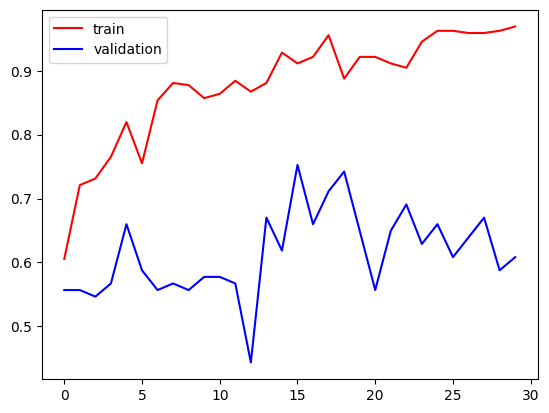

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [32]:
history.history['loss']

[8.175056457519531,
 3.9561052322387695,
 3.138056516647339,
 2.603145122528076,
 2.8163645267486572,
 2.8258635997772217,
 2.1273272037506104,
 1.2598944902420044,
 0.9541330933570862,
 1.8383374214172363,
 1.5687423944473267,
 1.8367990255355835,
 2.800097942352295,
 1.8382587432861328,
 1.2549959421157837,
 1.2963272333145142,
 1.021671175956726,
 0.3504478335380554,
 1.368455171585083,
 1.1430467367172241,
 0.8320390582084656,
 1.2116976976394653,
 1.0556100606918335,
 0.2574124038219452,
 0.36259010434150696,
 0.43663135170936584,
 0.39000678062438965,
 0.37383729219436646,
 0.3824501931667328,
 0.22711552679538727]

In [33]:
history.history['val_loss']

[2.515960216522217,
 2.5234971046447754,
 1.887763261795044,
 2.7211713790893555,
 2.0939903259277344,
 2.2822983264923096,
 5.834231853485107,
 3.993551015853882,
 7.360489368438721,
 5.793798923492432,
 7.610118865966797,
 5.522696495056152,
 11.125300407409668,
 8.37163257598877,
 6.394713878631592,
 3.02829647064209,
 2.420055627822876,
 2.499713182449341,
 3.9806556701660156,
 2.579134702682495,
 9.34156608581543,
 4.236352443695068,
 3.818812131881714,
 4.483716011047363,
 4.743023872375488,
 4.842160224914551,
 6.950920581817627,
 7.44967794418335,
 13.623138427734375,
 12.232150077819824]

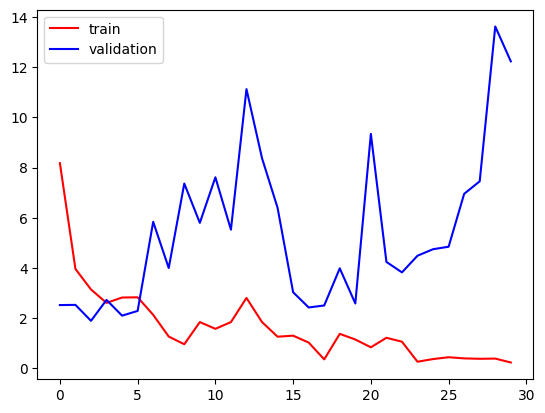

In [34]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

## ways to reduce overfitting
- Add more data
- Data Augmentation
- Dropout
- Batch Norm
- Reduce complexity : Reduce some of the layers and can see the model performance.

# Inference

In [64]:
import cv2
test_img = cv2.imread(r"d:\Aug_Sep_2025\Computer_Vision\7_CNN_on Custom_Data\apples-or-tomatoes-image-classification\train\apples\img_p1_18.jpeg")

#test_img = cv2.imread("/content/train/apples/img_p3_56.jpeg")
test_img

array([[[ 15,  14,  70],
        [  5,   4,  60],
        [  0,   0,  58],
        ...,
        [161, 170, 250],
        [171, 183, 255],
        [178, 191, 255]],

       [[ 13,  12,  68],
        [  4,   3,  59],
        [  0,   0,  58],
        ...,
        [154, 163, 243],
        [165, 177, 249],
        [174, 187, 255]],

       [[ 10,   9,  65],
        [  3,   2,  58],
        [  0,   0,  57],
        ...,
        [154, 160, 243],
        [167, 176, 250],
        [178, 188, 255]],

       ...,

       [[  0,  67, 134],
        [ 12,  77, 145],
        [  3,  61, 133],
        ...,
        [ 48,  94, 231],
        [ 60, 108, 240],
        [ 85, 134, 255]],

       [[  0,  63, 130],
        [  9,  74, 142],
        [  6,  64, 136],
        ...,
        [ 53,  99, 236],
        [ 69, 117, 249],
        [ 83, 132, 255]],

       [[  0,  61, 128],
        [  6,  71, 139],
        [ 10,  68, 140],
        ...,
        [ 53,  99, 236],
        [ 73, 121, 253],
        [ 78, 127, 255]]

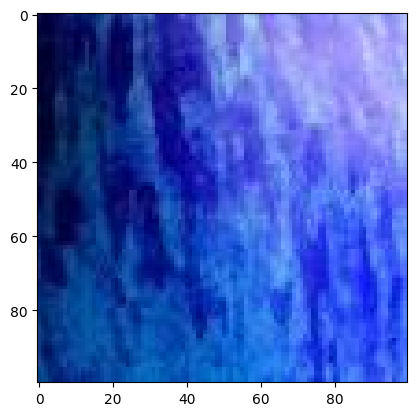

In [65]:
plt.imshow(test_img)

In [66]:
test_img.shape

(100, 100, 3)

In [67]:
test_img = cv2.resize(test_img,(256,256))

In [68]:
test_img.shape

(256, 256, 3)

In [69]:
test_input = test_img.reshape((1,256,256,3))

In [70]:
result = model.predict(test_input)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[1.]], dtype=float32)

In [71]:
if int(result[0][0]) == 0:
  print("Apple")

else:
  print("Tomato")

Tomato
